# Week 1 — Setup & Your First Reproducible Result

**FIN 7057 · Financial Machine Learning & AI**

This notebook is the companion to **Chapter 1 (The Financial ML Mindset)** and **Chapter 2 (The
Research Workflow & Tools)**. It backs the chapters' ▶ Demo callouts with runnable, offline code.

The Week 1 job is not a model — it is a *workflow*. We establish the thirty-second reproducibility
ritual, the time-indexed `DataFrame` mental model, simple vs. log returns, and the humbling naive
baseline that every later model must beat. Everything runs **offline and deterministically** using
the course's `finmlsim` package (simulations) and its bundled Ken French data (real markets).

Sections, mapped to the chapter Demo callouts:

- **§1–3** — Environment check, package versions, seed & date range (Ch. 2 Demo §1–3).
- **§4–6** — Load prices (real, with synthetic fallback), simple vs. log returns, price-vs-returns plot (Ch. 2 Demo §4–9).
- **§7** — The naive "predict up tomorrow" baseline, and a slightly cleverer rule (Ch. 1 Demo §7).
- **§8** — The multiple-testing mirage: best Sharpe of N pure-noise strategies (Ch. 1, Fig. 2).
- **§9** — The reproducibility checklist every future assignment must satisfy.

In [1]:
# The standard offline header. Run from the notebooks/ directory; this makes finmlsim importable
# without installing it, and pulls in the scientific stack.
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import finmlsim as fms
from finmlsim import simulate as sim, stylized as sty, metrics as met, data

## 1. Environment check

A result you cannot reproduce is not a result. The first thing in any analysis is a short, boring
record of *what you ran it with*. Print the versions; in a real submission these go into a
`requirements.txt` beside the notebook.

In [2]:
import platform, sklearn, scipy
print("Python    ", sys.version.split()[0], "on", platform.system())
for m in (np, pd, sklearn, scipy, fms):
    print(f"{m.__name__:>12}  {m.__version__}")

Python     3.12.2 on Darwin
       numpy  1.26.4
      pandas  2.2.3
     sklearn  1.7.1
       scipy  1.16.1
    finmlsim  0.4.1


## 2. Install extras (Colab only)

This notebook needs nothing beyond the scientific stack plus `finmlsim`, which lives in the repo.
On Colab you would clone the course repo and install `requirements.txt`; for an archival result,
also preserve the resolved environment because the repository file specifies minimum versions. Locally,
the header in §0 already put `finmlsim` on the path. There is **no network call** anywhere in this
notebook.

In [3]:
# On Colab, you would run (uncomment):
# !pip install -q numpy pandas matplotlib scikit-learn scipy statsmodels
# and clone the course repo so `import finmlsim` resolves. Nothing to install here.
print("finmlsim version", fms.__version__, "— imported from", os.path.dirname(fms.__file__))

finmlsim version 0.4.1 — imported from /Users/smc77/Dropbox/aiinfinance/finmlsim


## 3. Reproducibility first — the thirty-second ritual

> **▶ Demo (Ch. 2, §1–3).** Verify the environment, print versions, and set the seed and date
> range *up front*. Do this before anything else, every time.

Five lines buy you a result you can defend a year later: a fixed **seed**, an explicit **date
window**, the exact **instrument**, and (above) the **environment**. Skipping them is the
difference between research and an anecdote.

In [4]:
SEED = 42
rng = np.random.default_rng(SEED)     # the modern NumPy generator; pass `seed` everywhere
np.random.seed(SEED)                  # also pin the legacy global RNG, for libraries that use it

TICKER     = "US-MKT"                 # the real value-weighted US market (Ken French), our offline SPY
START_DATE = "2000-01-01"
END_DATE   = "2024-12-31"
print(f"seed={SEED}  instrument={TICKER}  window={START_DATE}..{END_DATE}")

seed=42  instrument=US-MKT  window=2000-01-01..2024-12-31


## 4. Get data — real, with a synthetic fallback

> **▶ Demo (Ch. 2, §4–9).** Load real prices (with a synthetic fallback so the notebook runs
> offline), compute simple and log returns, plot price vs. returns, run the naive baseline, and
> finish with the reproducibility checklist.

Free price feeds (Yahoo, etc.) require a network and silently back-adjust history — a
reproducibility hazard. We instead use the **real value-weighted US market** from the bundled Ken
French data library: an offline, versioned current reconstruction with a far longer history than any ETF. It
is the principled stand-in for "SPY." If even that were unavailable we fall back to a `finmlsim`
simulation, so the notebook *always* runs.

In [5]:
def load_prices(start, end, seed=SEED):
    "Return a price Series. Real US market if available; else a deterministic simulation."
    try:
        mkt_ret = data.market_return(start=start, end=end).dropna()   # daily simple returns, decimal
        prices = 100.0 * (1.0 + mkt_ret).cumprod()                    # index level, start = 100
        prices.name = "price"
        source = "real: Ken French value-weighted US market (offline)"
    except Exception as e:                                            # pragma: no cover
        idx = pd.bdate_range(start, end)
        r = sim.gaussian(n=len(idx), mu=0.0003, sigma=0.01, seed=seed)
        prices = pd.Series(sty.to_prices(r), index=idx, name="price")
        source = f"synthetic fallback (finmlsim.gaussian, seed={seed}): {e}"
    return prices, source

prices, SOURCE = load_prices(START_DATE, END_DATE)
print("data source:", SOURCE)
print(prices.head(3)); print("...\n", prices.tail(3))
print("\nThe workhorse object: a time-indexed Series.", type(prices.index).__name__,
      "rows:", len(prices))

data source: real: Ken French value-weighted US market (offline)
date
2000-01-03    99.310000
2000-01-04    95.297876
2000-01-05    95.231167
Name: price, dtype: float64
...
 date
2024-12-27    681.263504
2024-12-30    673.973985
2024-12-31    671.008499
Name: price, dtype: float64

The workhorse object: a time-indexed Series. DatetimeIndex rows: 6289


## 5. Simple vs. log returns

Two definitions, and the difference matters more than beginners expect:

- **Simple return** $r_t = P_t/P_{t-1} - 1$ — *adds across assets* (portfolio aggregation).
- **Log return** $\ell_t = \ln(P_t/P_{t-1})$ — *adds across time* (compounding, time-series work).

For small daily moves they agree to the fourth decimal. We confirm that, and anchor the scale of
what we are working with: annualized mean, annualized volatility, and a "naive Sharpe."

In [6]:
df = prices.to_frame()
df["simple_ret"] = prices.pct_change()                 # P_t / P_{t-1} - 1
df["log_ret"]    = np.log(prices).diff()               # ln P_t - ln P_{t-1}
df = df.dropna()

# They differ only in the 4th decimal for daily data:
diff = (df["simple_ret"] - df["log_ret"]).abs()
print(f"max |simple - log| daily return: {diff.max():.6f}")
print(df[["simple_ret", "log_ret"]].head().round(6))

ann_mean = df["log_ret"].mean() * 252
ann_vol  = df["log_ret"].std() * np.sqrt(252)
naive_sharpe = met.sharpe(df["simple_ret"].values)     # finmlsim metric, 252/yr
print(f"\nAnnualized mean return : {ann_mean:6.2%}")
print(f"Annualized volatility  : {ann_vol:6.2%}")
print(f"Naive Sharpe ratio     : {naive_sharpe:5.2f}")

max |simple - log| daily return: 0.007833
            simple_ret   log_ret
date                            
2000-01-04     -0.0404 -0.041239
2000-01-05     -0.0007 -0.000700
2000-01-06     -0.0072 -0.007226
2000-01-07      0.0323  0.031789
2000-01-10      0.0177  0.017545

Annualized mean return :  7.66%
Annualized volatility  : 19.71%
Naive Sharpe ratio     :  0.49


A concrete reason the two definitions are not interchangeable: an asset that gains 50% then loses
50% is *down 25%*, not flat. Simple gross returns multiply through time; log returns express
the same compounding as a sum.

In [7]:
gains = pd.Series([0.50, -0.50])                       # +50% then -50%
print("Arithmetic mean of returns :", gains.mean(), "  (not the compound return)")
print("Simple gross returns give  : $", 100 * (1 + gains).prod(), sep="")
log_rets = np.log(1 + gains)
print("Sum of log returns        :", round(log_rets.sum(), 4),
      "-> exp =", round(np.exp(log_rets.sum()), 4), "= the same 25% loss")

Arithmetic mean of returns : 0.0   (not the compound return)
Simple gross returns give  : $75.0
Sum of log returns        : -0.2877 -> exp = 0.75 = the same 25% loss


## 6. Price vs. returns — the picture behind "model returns, not prices"

The price level is highly persistent; the returns fluctuate around a much more stable center.
Returns are the default for standalone prediction, while Chapter 3 develops the exceptions.

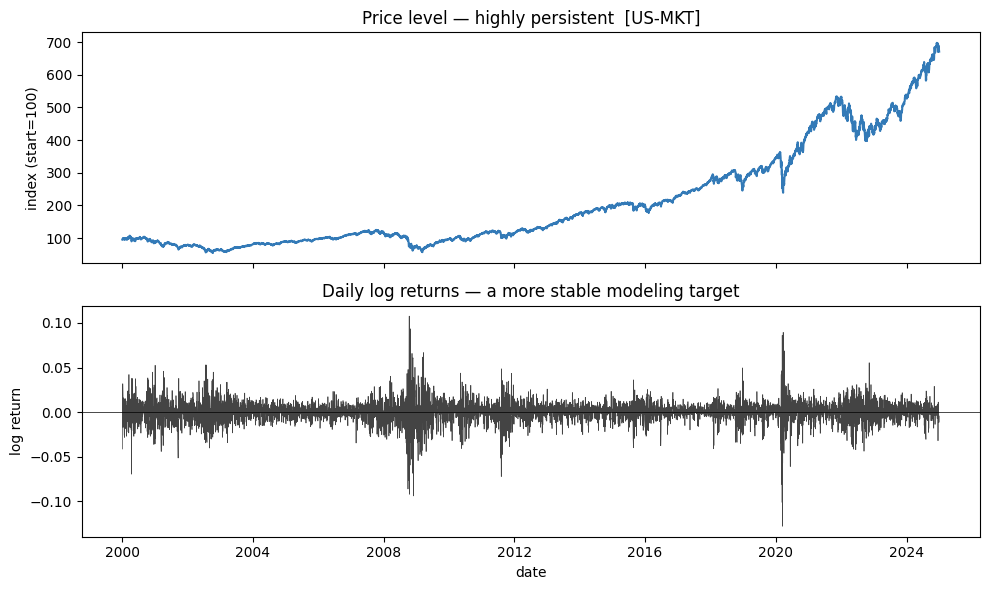

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(df.index, df["price"], color="#337ab7")
ax[0].set_title(f"Price level — highly persistent  [{TICKER}]")
ax[0].set_ylabel("index (start=100)")
ax[1].plot(df.index, df["log_ret"], lw=0.5, color="#444444")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_title("Daily log returns — a more stable modeling target")
ax[1].set_ylabel("log return"); ax[1].set_xlabel("date")
plt.tight_layout(); plt.show()

## 7. The humbling baseline

> **▶ Demo (Ch. 1, §7).** Build the most naive "predict up tomorrow" classifier. Its accuracy
> hovers near 50%. Then let a slightly cleverer rule try to beat it — and watch it barely move the
> needle. Predicting markets is hard; your first instinct should be humility, not confidence.

The mental model: a feature may use information available by its stated forecast timestamp; the
**target** must become known afterward. Here the return recorded at *t* predicts the return recorded
at *t+1*. A trading implementation would still need an executable entry-price convention.

In [9]:
ret = df["simple_ret"]
next_ret = ret.shift(-1)                               # numeric target stays missing at the boundary
valid = next_ret.notna()
target_up = (next_ret.loc[valid] > 0).astype(int)      # label at t: is the return recorded at t+1 positive?

# Baseline A: "always predict up" (the market drifts up, so this is the majority class).
acc_always_up = (target_up == 1).mean()

# Baseline B: "tomorrow repeats today's sign" (a slightly cleverer momentum rule).
pred_momentum = (ret.loc[valid] > 0).astype(int)       # feature is available at the forecast timestamp
aligned = pd.concat([pred_momentum, target_up], axis=1)
acc_momentum = (aligned.iloc[:, 0] == aligned.iloc[:, 1]).mean()

# The true majority-class baseline (predict whichever class is more common):
majority = max(target_up.mean(), 1 - target_up.mean())

print(f"Up-day frequency (always-up accuracy) : {acc_always_up:6.2%}")
print(f"'tomorrow repeats today' accuracy      : {acc_momentum:6.2%}")
print(f"Majority-class baseline                : {majority:6.2%}")
print("\nThe clever rule barely moves the needle. This near-50% wall is the plain face of the field.")

Up-day frequency (always-up accuracy) : 53.86%
'tomorrow repeats today' accuracy      : 48.27%
Majority-class baseline                : 53.86%

The clever rule barely moves the needle. This near-50% wall is the plain face of the field.


## 8. The cost of fooling yourself — the multiple-testing mirage

This reproduces **Chapter 1, Figure 2** *interactively*: the best Sharpe among **N pure-noise**
strategies climbs steadily with how many you try, even though none has any edge. Change `N_grid`
or `N_TRIALS` and re-run — the mirage is robust.

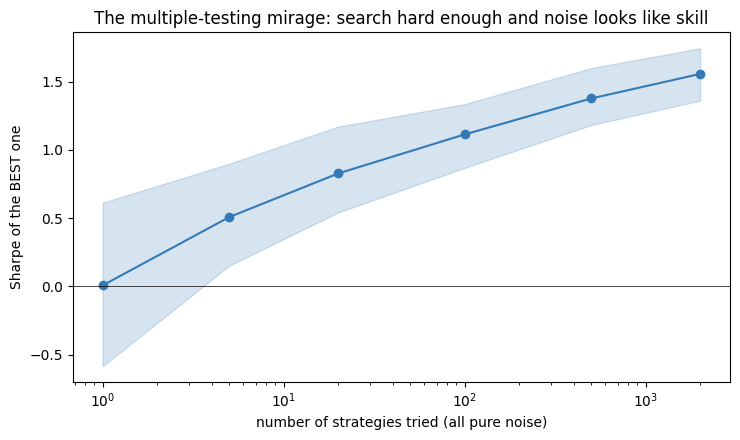

  try     1 noise strategies -> best Sharpe ≈ 0.01
  try     5 noise strategies -> best Sharpe ≈ 0.51
  try    20 noise strategies -> best Sharpe ≈ 0.83
  try   100 noise strategies -> best Sharpe ≈ 1.11
  try   500 noise strategies -> best Sharpe ≈ 1.38
  try  2000 noise strategies -> best Sharpe ≈ 1.56


In [10]:
def best_sharpe_of_noise(N, T=252*5, trials=200, seed=0):
    "Mean (and 10-90 pct band) of the BEST Sharpe among N pure-noise strategies."
    g = np.random.default_rng(seed)
    maxes = []
    for _ in range(trials):
        rets = g.standard_normal((T, N)) * 0.01         # zero-mean: NO edge by construction
        sh = rets.mean(0) / rets.std(0) * np.sqrt(252)
        maxes.append(sh.max())
    return np.mean(maxes), np.percentile(maxes, 10), np.percentile(maxes, 90)

N_grid   = [1, 5, 20, 100, 500, 2000]                  # <- vary me
N_TRIALS = 200
best, p10, p90 = zip(*[best_sharpe_of_noise(N, trials=N_TRIALS, seed=0) for N in N_grid])

plt.figure(figsize=(7.5, 4.5))
plt.fill_between(N_grid, p10, p90, alpha=0.2, color="#337ab7")
plt.plot(N_grid, best, "o-", color="#337ab7")
plt.xscale("log"); plt.axhline(0, color="k", lw=0.5)
plt.xlabel("number of strategies tried (all pure noise)")
plt.ylabel("Sharpe of the BEST one")
plt.title("The multiple-testing mirage: search hard enough and noise looks like skill")
plt.tight_layout(); plt.show()

for N, b in zip(N_grid, best):
    print(f"  try {N:>5} noise strategies -> best Sharpe ≈ {b:4.2f}")

## 9. The reproducibility checklist

Every future assignment must satisfy this minimum record. A project intended for archival
reproduction also needs the code commit, resolved environment, data vintage or snapshot checksum,
configuration, entry command, and expected outputs described in Chapter 2:

1. **Fixed random seed** — set above (`SEED = 42`, both NumPy generators).
2. **Explicit train/test dates** — stated up front (`START_DATE`, `END_DATE`).
3. **Documented data source** — printed (`SOURCE`); exact instrument and window.
4. **Recorded environment** — versions printed in §1; preserve a resolved lock or environment export.
5. **Runs top to bottom** — this notebook has no hidden state; *Restart & Run All* reproduces every number.

In [11]:
checklist = {
    "1. fixed seed":            SEED,
    "2. explicit dates":        f"{START_DATE} .. {END_DATE}",
    "3. documented source":     SOURCE,
    "4. recorded environment":  f"numpy {np.__version__}, pandas {pd.__version__}, finmlsim {fms.__version__}",
    "5. runs top to bottom":    "Restart & Run All -> identical output",
}
for k, v in checklist.items():
    print(f"{k:28s}: {v}")
print("\nThis is the spine: data -> features -> models -> evaluation -> decisions -> risk.")
print("Week 1 sits at 'data'. Everything that follows is built on this reproducible foundation.")

1. fixed seed               : 42
2. explicit dates           : 2000-01-01 .. 2024-12-31
3. documented source        : real: Ken French value-weighted US market (offline)
4. recorded environment     : numpy 1.26.4, pandas 2.2.3, finmlsim 0.4.1
5. runs top to bottom       : Restart & Run All -> identical output

This is the spine: data -> features -> models -> evaluation -> decisions -> risk.
Week 1 sits at 'data'. Everything that follows is built on this reproducible foundation.
